# 08 — Frequency-domain classifiers

Train and compare radial-only and hybrid FFT Logistic Regression models. Model selection uses validation data, while the locked configurations are evaluated once on the held-out test split.


## Feature representations

`radial`: 64 annular energy features. `hybrid`: the same 64 radial features plus 256 cells from a 16×16 log-power grid, for 320 features total. The radial baseline keeps its previously selected `C=0.01`; regularization for the new hybrid model is selected by validation log loss.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "experiments.yaml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT))

from src.data.config import load_config
from src.features import (
    compute_log_power_grid,
    compute_normalized_power_spectrum,
    compute_radial_energy_profile,
    image_to_luminance,
)

config = load_config()
SEED = config["seed"]
MANIFEST_PATH = REPO_ROOT / "data" / "dataset.csv"
PROCESSED_ROOT = REPO_ROOT / "data" / "processed"
RADIAL_BINS = 64
GRID_SIZE = 16
THRESHOLD = 0.5

manifest = pd.read_csv(MANIFEST_PATH)

In [2]:
def extract_frequency_features(
    rows: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extract radial, hybrid, and label arrays for manifest rows."""
    radial = np.empty((len(rows), RADIAL_BINS), dtype=np.float32)
    grid = np.empty((len(rows), GRID_SIZE * GRID_SIZE), dtype=np.float32)

    for index, filename in enumerate(rows["filename"]):
        image_path = PROCESSED_ROOT / filename
        with Image.open(image_path) as image:
            luminance = image_to_luminance(image)
        power = compute_normalized_power_spectrum(luminance)
        radial[index] = compute_radial_energy_profile(power, bins=RADIAL_BINS)
        grid[index] = compute_log_power_grid(power, grid_size=GRID_SIZE).ravel()

    hybrid = np.concatenate((radial, grid), axis=1)
    labels = rows["label"].map({"real": 0, "ai": 1}).to_numpy(dtype=np.int64)
    return radial, hybrid, labels


def classification_metrics(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:
    predictions = (probabilities >= THRESHOLD).astype(np.int64)
    return {
        "loss": log_loss(labels, probabilities),
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "roc_auc": roc_auc_score(labels, probabilities),
    }


def build_model(c_value: float) -> Pipeline:
    return Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(C=c_value, max_iter=3000, random_state=SEED),
            ),
        ]
    )

## Train and validation feature extraction

Each image FFT is calculated once and used to create both representations. This is the longest step.

In [3]:
train_frame = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_frame = manifest[manifest["split"] == "val"].reset_index(drop=True)

print(f"Extracting train features from {len(train_frame):,} images...")
X_train_radial, X_train_hybrid, y_train = extract_frequency_features(train_frame)
print(f"Extracting validation features from {len(val_frame):,} images...")
X_val_radial, X_val_hybrid, y_val = extract_frequency_features(val_frame)

print("Radial shapes:", X_train_radial.shape, X_val_radial.shape)
print("Hybrid shapes:", X_train_hybrid.shape, X_val_hybrid.shape)
print("Class counts:", np.bincount(y_train), np.bincount(y_val))

Extracting train features from 9,800 images...
Extracting validation features from 2,100 images...
Radial shapes: (9800, 64) (2100, 64)
Hybrid shapes: (9800, 320) (2100, 320)
Class counts: [4900 4900] [1050 1050]


## Radial-only baseline selection

Compare four regularization strengths using validation log loss. This preserves the selection evidence for the simpler 64-feature baseline before introducing the hybrid representation.


In [4]:
candidate_c_values = [0.01, 0.1, 1.0, 10.0]
radial_selection_rows = []
radial_fitted_models = {}

for c_value in candidate_c_values:
    candidate_model = build_model(c_value)
    candidate_model.fit(X_train_radial, y_train)
    val_probabilities = candidate_model.predict_proba(X_val_radial)[:, 1]
    metrics = classification_metrics(y_val, val_probabilities)
    radial_selection_rows.append({"C": c_value, **metrics})
    radial_fitted_models[c_value] = candidate_model

radial_selection_results = pd.DataFrame(radial_selection_rows).sort_values("loss").reset_index(drop=True)
radial_best_c = float(radial_selection_results.iloc[0]["C"])
radial_model = radial_fitted_models[radial_best_c]
display(radial_selection_results)
print(f"Selected radial C: {radial_best_c}")

,C,loss,accuracy,precision,recall,f1,roc_auc
0,0.01,0.658426,0.649524,0.616296,0.792381,0.693333,0.702157
1,0.10,0.661834,0.646190,0.613957,0.787619,0.690029,0.696511
2,1.00,0.663191,0.643333,0.611564,0.785714,0.687787,0.695217
3,10.00,0.663223,0.643333,0.611399,0.786667,0.688047,0.695297


Selected C: 0.01


## Learned frequency weights

Positive coefficients push predictions toward AI; negative coefficients push them toward real. Because features are standardized inside the pipeline, coefficient magnitudes are comparable across radial bins. Correlated neighboring bins mean individual coefficients should be interpreted as model behavior, not causal effects.

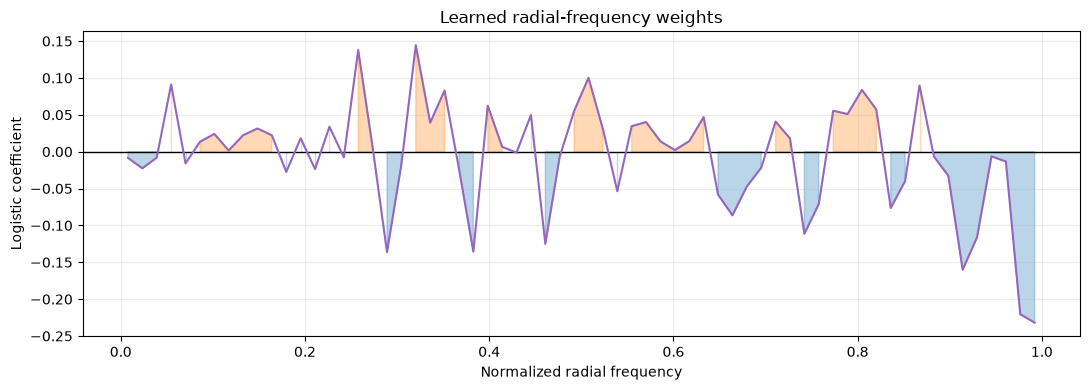

In [5]:
frequency_axis = (np.arange(RADIAL_BINS) + 0.5) / RADIAL_BINS
coefficients = radial_model.named_steps["classifier"].coef_[0]

fig, axis = plt.subplots(figsize=(11, 4))
axis.axhline(0, color="black", linewidth=1)
axis.plot(frequency_axis, coefficients, color="tab:purple")
axis.fill_between(
    frequency_axis, 0, coefficients, where=coefficients >= 0, color="tab:orange", alpha=0.3
)
axis.fill_between(
    frequency_axis, 0, coefficients, where=coefficients < 0, color="tab:blue", alpha=0.3
)
axis.set_xlabel("Normalized radial frequency")
axis.set_ylabel("Logistic coefficient")
axis.set_title("Learned radial-frequency weights")
axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Model selection and direct validation comparison

Refit the fixed radial baseline at `C=0.01`. Select the hybrid `C` from `[0.001, 0.01, 0.1, 1.0]` by validation loss, then compare the two best representations on identical validation examples.

In [6]:
models = {}
selection_rows = []

radial_model = build_model(0.01)
radial_model.fit(X_train_radial, y_train)
radial_probabilities = radial_model.predict_proba(X_val_radial)[:, 1]
selection_rows.append(
    {"representation": "radial", "C": 0.01, **classification_metrics(y_val, radial_probabilities)}
)
models[("radial", 0.01)] = radial_model

for c_value in [0.001, 0.01, 0.1, 1.0]:
    model = build_model(c_value)
    model.fit(X_train_hybrid, y_train)
    probabilities = model.predict_proba(X_val_hybrid)[:, 1]
    selection_rows.append(
        {"representation": "hybrid", "C": c_value, **classification_metrics(y_val, probabilities)}
    )
    models[("hybrid", c_value)] = model

selection_results = pd.DataFrame(selection_rows)
hybrid_results = selection_results[selection_results["representation"] == "hybrid"]
best_hybrid_c = float(hybrid_results.sort_values("loss").iloc[0]["C"])
best_models = {
    "radial": radial_model,
    "hybrid": models[("hybrid", best_hybrid_c)],
}

display(selection_results.sort_values(["representation", "loss"]).reset_index(drop=True))
print(f"Selected hybrid C: {best_hybrid_c}")

,representation,C,loss,accuracy,precision,recall,f1,roc_auc
0,hybrid,0.010,0.574431,0.680000,0.706783,0.615238,0.657841,0.766143
1,hybrid,0.100,0.575405,0.684286,0.706952,0.629524,0.665995,0.763419
2,hybrid,1.000,0.578586,0.681905,0.704936,0.625714,0.662967,0.759248
3,hybrid,0.001,0.581035,0.683810,0.721839,0.598095,0.654167,0.761741
4,radial,0.010,0.658426,0.649524,0.616296,0.792381,0.693333,0.702157


Selected hybrid C: 0.01


In [7]:
validation_features = {"radial": X_val_radial, "hybrid": X_val_hybrid}
validation_probabilities = {}
comparison_rows = []

for representation, model in best_models.items():
    probabilities = model.predict_proba(validation_features[representation])[:, 1]
    validation_probabilities[representation] = probabilities
    comparison_rows.append(
        {"representation": representation, **classification_metrics(y_val, probabilities)}
    )

validation_comparison = pd.DataFrame(comparison_rows).sort_values("loss").reset_index(drop=True)
selected_representation = str(validation_comparison.iloc[0]["representation"])
selected_model = best_models[selected_representation]
display(validation_comparison)
print(f"Selected representation: {selected_representation}")

,representation,loss,accuracy,precision,recall,f1,roc_auc
0,hybrid,0.574431,0.680000,0.706783,0.615238,0.657841,0.766143
1,radial,0.658426,0.649524,0.616296,0.792381,0.693333,0.702157


Selected representation: hybrid


## Per-generator validation comparison

Compare both representations on matched 150-AI/150-real validation groups.

In [8]:
per_generator_rows = []

for representation, probabilities in validation_probabilities.items():
    predictions = val_frame[["label", "generator", "source_group"]].copy()
    predictions["label_index"] = y_val
    predictions["probability_ai"] = probabilities

    for generator in config["generators"]:
        group = predictions[
            ((predictions["label"] == "ai") & (predictions["generator"] == generator))
            | ((predictions["label"] == "real") & (predictions["source_group"] == generator))
        ]
        metrics = classification_metrics(
            group["label_index"].to_numpy(), group["probability_ai"].to_numpy()
        )
        per_generator_rows.append(
            {"representation": representation, "generator": generator, **metrics}
        )

per_generator_comparison = pd.DataFrame(per_generator_rows)
display(per_generator_comparison.pivot(index="generator", columns="representation", values=["f1", "roc_auc"]))

f1             roc_auc          
representation    hybrid    radial    hybrid    radial
generator                                             
adm             0.637993  0.724138  0.726978  0.706089
biggan          0.879765  0.790451  0.988133  0.870711
glide           0.875740  0.802139  0.967822  0.873111
midjourney      0.504000  0.652439  0.683111  0.653689
sdv1_5          0.491803  0.622642  0.670089  0.616578
vqdm            0.569231  0.565079  0.676089  0.541378
wukong          0.492063  0.658824  0.654489  0.662933

## Hybrid model weights

The first panel shows radial coefficients. The second restores the 256 grid coefficients to 16×16, revealing which directions and spectral regions push the hybrid model toward AI (red) or real (blue). Coefficients describe a correlated linear model and are not causal explanations.

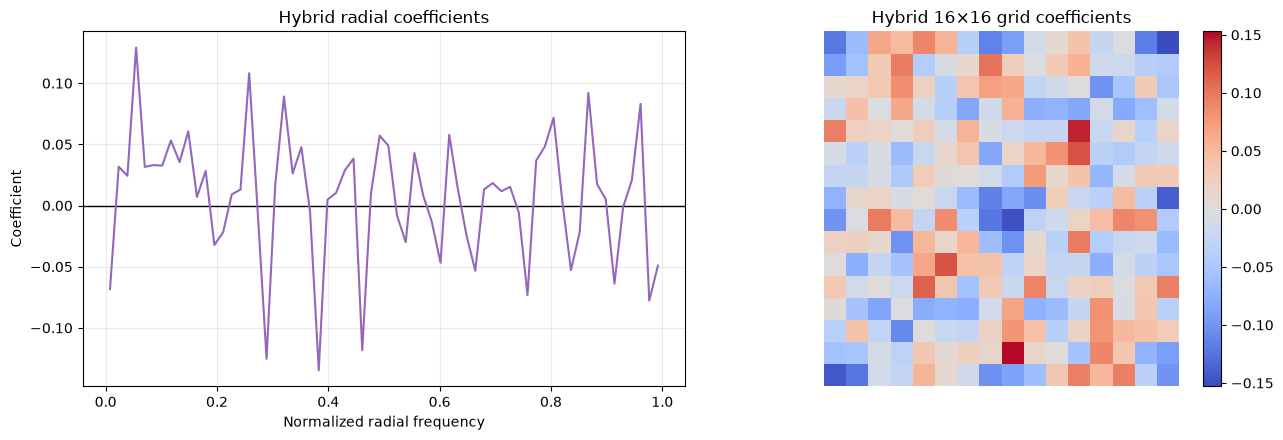

In [9]:
hybrid_coefficients = best_models["hybrid"].named_steps["classifier"].coef_[0]
radial_coefficients = hybrid_coefficients[:RADIAL_BINS]
grid_coefficients = hybrid_coefficients[RADIAL_BINS:].reshape(GRID_SIZE, GRID_SIZE)
frequency_axis = (np.arange(RADIAL_BINS) + 0.5) / RADIAL_BINS
grid_limit = np.max(np.abs(grid_coefficients))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].axhline(0, color="black", linewidth=1)
axes[0].plot(frequency_axis, radial_coefficients, color="tab:purple")
axes[0].set_title("Hybrid radial coefficients")
axes[0].set_xlabel("Normalized radial frequency")
axes[0].set_ylabel("Coefficient")
axes[0].grid(alpha=0.25)

grid_image = axes[1].imshow(
    grid_coefficients, cmap="coolwarm", vmin=-grid_limit, vmax=grid_limit
)
axes[1].set_title("Hybrid 16×16 grid coefficients")
axes[1].axis("off")
fig.colorbar(grid_image, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Final test evaluation

The radial and hybrid representations, regularization values, and threshold are now fixed. Extract test features once and evaluate both predefined models without further tuning.

In [10]:
test_frame = manifest[manifest["split"] == "test"].reset_index(drop=True)
print(f"Extracting test features from {len(test_frame):,} images...")
X_test_radial, X_test_hybrid, y_test = extract_frequency_features(test_frame)
print("Radial test shape:", X_test_radial.shape)
print("Hybrid test shape:", X_test_hybrid.shape)
print("Test class counts:", np.bincount(y_test))

Extracting test features from 2,100 images...
Radial test shape: (2100, 64)
Hybrid test shape: (2100, 320)
Test class counts: [1050 1050]


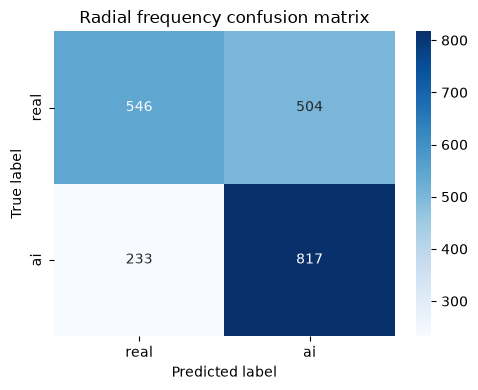

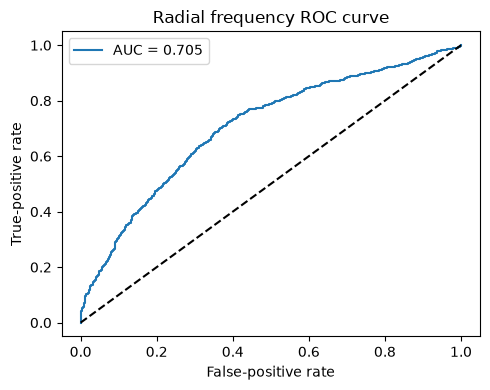

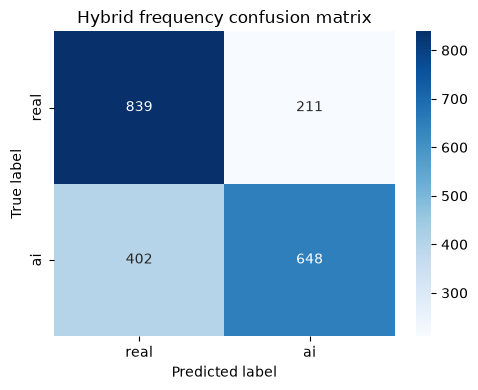

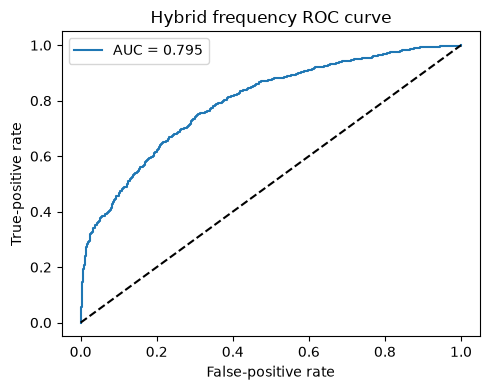

,representation,loss,accuracy,precision,recall,f1,roc_auc
0,hybrid,0.551112,0.708095,0.754366,0.617143,0.678889,0.794697
1,radial,0.665258,0.649048,0.618471,0.778095,0.689161,0.704762


Radial per-generator metrics:


,generator,n_ai,n_real,loss,accuracy,precision,recall,f1,roc_auc
0,biggan,150,150,0.583854,0.763333,0.678733,1.000000,0.808625,0.883022
1,glide,150,150,0.585066,0.720000,0.643478,0.986667,0.778947,0.853956
2,vqdm,150,150,0.728709,0.593333,0.592105,0.600000,0.596026,0.582044
3,sdv1_5,150,150,0.720269,0.550000,0.543353,0.626667,0.582043,0.617378
4,adm,150,150,0.651714,0.640000,0.609375,0.780000,0.684211,0.680089
5,midjourney,150,150,0.664739,0.643333,0.616216,0.760000,0.680597,0.671022
6,wukong,150,150,0.722454,0.633333,0.619048,0.693333,0.654088,0.648311


Hybrid per-generator metrics:


,generator,n_ai,n_real,loss,accuracy,precision,recall,f1,roc_auc
0,biggan,150,150,0.320878,0.903333,0.837989,1.000000,0.911854,0.989022
1,glide,150,150,0.372329,0.890000,0.823204,0.993333,0.900302,0.966444
2,vqdm,150,150,0.629612,0.653333,0.721154,0.500000,0.590551,0.724267
3,sdv1_5,150,150,0.644269,0.606667,0.663265,0.433333,0.524194,0.697778
4,adm,150,150,0.599273,0.666667,0.715517,0.553333,0.624060,0.743644
5,midjourney,150,150,0.650270,0.593333,0.666667,0.373333,0.478632,0.704756
6,wukong,150,150,0.641153,0.643333,0.721649,0.466667,0.566802,0.728267


In [11]:
import json

import joblib
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

METRICS_ROOT = REPO_ROOT / "results" / "metrics" / "frequency"
FIGURES_ROOT = REPO_ROOT / "results" / "figures" / "frequency"
MODELS_ROOT = REPO_ROOT / "results" / "models" / "frequency"
test_features = {"radial": X_test_radial, "hybrid": X_test_hybrid}
test_summary_rows = []
test_results = {}

for representation, model in best_models.items():
    probabilities = model.predict_proba(test_features[representation])[:, 1]
    predicted_indices = (probabilities >= THRESHOLD).astype(np.int64)
    metrics = classification_metrics(y_test, probabilities)

    predictions = test_frame[
        ["filename", "label", "generator", "source_group"]
    ].copy()
    predictions["label_index"] = y_test
    predictions["probability_ai"] = probabilities
    predictions["prediction_index"] = predicted_indices
    predictions["prediction"] = np.where(predicted_indices == 1, "ai", "real")

    per_generator_rows = []
    for generator in config["generators"]:
        group = predictions[
            ((predictions["label"] == "ai") & (predictions["generator"] == generator))
            | ((predictions["label"] == "real") & (predictions["source_group"] == generator))
        ]
        group_metrics = classification_metrics(
            group["label_index"].to_numpy(), group["probability_ai"].to_numpy()
        )
        per_generator_rows.append(
            {
                "generator": generator,
                "n_ai": int((group["label"] == "ai").sum()),
                "n_real": int((group["label"] == "real").sum()),
                **group_metrics,
            }
        )
    per_generator = pd.DataFrame(per_generator_rows)

    metrics_dir = METRICS_ROOT / representation
    figures_dir = FIGURES_ROOT / representation
    metrics_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)
    MODELS_ROOT.mkdir(parents=True, exist_ok=True)

    (metrics_dir / "test_metrics.json").write_text(
        json.dumps(metrics, indent=2), encoding="utf-8"
    )
    predictions.to_csv(metrics_dir / "test_predictions.csv", index=False)
    per_generator.to_csv(metrics_dir / "per_generator_metrics.csv", index=False)
    joblib.dump(model, MODELS_ROOT / f"{representation}_logistic_regression.joblib")

    matrix = confusion_matrix(y_test, predicted_indices, labels=[0, 1])
    fig, axis = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues",
        xticklabels=["real", "ai"], yticklabels=["real", "ai"], ax=axis
    )
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("True label")
    axis.set_title(f"{representation.title()} frequency confusion matrix")
    fig.tight_layout()
    fig.savefig(figures_dir / "confusion_matrix.png", dpi=150)
    plt.show()

    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    fig, axis = plt.subplots(figsize=(5, 4))
    axis.plot(false_positive_rate, true_positive_rate, label=f"AUC = {metrics['roc_auc']:.3f}")
    axis.plot([0, 1], [0, 1], linestyle="--", color="black")
    axis.set_xlabel("False-positive rate")
    axis.set_ylabel("True-positive rate")
    axis.set_title(f"{representation.title()} frequency ROC curve")
    axis.legend()
    fig.tight_layout()
    fig.savefig(figures_dir / "roc_curve.png", dpi=150)
    plt.show()

    test_summary_rows.append({"representation": representation, **metrics})
    test_results[representation] = {
        "metrics": metrics, "predictions": predictions, "per_generator": per_generator
    }

test_summary = pd.DataFrame(test_summary_rows).sort_values("loss").reset_index(drop=True)
display(test_summary)
for representation in ("radial", "hybrid"):
    print(f"{representation.title()} per-generator metrics:")
    display(test_results[representation]["per_generator"])

## Finalization boundary

After these test results are viewed, do not change the representations, regularization, scaler, or threshold based on test performance. Any later frequency model must be reported as a separate experiment.